In [45]:
import os
import gc
import json
import faiss
import torch
import numpy as np
import time
from datetime import datetime
from pathlib import Path
from datasets import load_dataset
from collections import defaultdict

import matplotlib.pyplot as plt

from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
)
from huggingface_hub import ModelCard
from sentence_transformers import SentenceTransformer
from peft import (
    LoraConfig,
    get_peft_model,
    PeftModel,
    TaskType,
)
from trl import SFTConfig, SFTTrainer

In [46]:
def save_cache(data, path):
    path = Path(path)
    temp_path = path.with_name(path.name + ".tmp")

    with temp_path.open("w", encoding="utf-8") as f:
        json.dump(data, f, ensure_ascii=False, indent=2)

    temp_path.replace(path)


def load_cache(path):
    path = Path(path)
    if path.exists():
        with path.open("r", encoding="utf-8") as f:
            return json.load(f)
    return []


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

MODEL_ID = "Qwen/Qwen2.5-0.5B-Instruct"
QWEN_DEFAULT_SYSTEM = (
    "You are Qwen, created by Alibaba Cloud. You are a helpful assistant."
)
MODEL_DIR = "model/results_lora"
HUB_REPO = "maikerdr/EnerGuia-0.5B"

In [47]:
KNOWLEDGE_BASE = r"""
# Base de Conhecimento — Direitos do Consumidor de Energia Elétrica no Brasil

## Fontes Normativas Principais

Os direitos e deveres do consumidor de energia elétrica são regulados pela
**Resolução Normativa ANEEL nº 1.000/2021** (REN 1.000), que consolidou mais de
60 normas anteriores em um único documento com linguagem simplificada. Ela foi
atualizada diversas vezes desde então, incluindo pela REN ANEEL nº 1.147, de
09/12/2025.

A REN 1.000 é complementada por:
- **Lei nº 8.078/1990** — Código de Defesa do Consumidor (CDC), aplicável
  subsidiariamente às relações com distribuidoras.
- **Lei nº 15.235/2025** — Conversão da MP nº 1.300/2025, que reformulou a
  Tarifa Social e criou o Desconto Social (programa "Luz do Povo").
- **Lei nº 14.300/2022** — Marco Legal da Geração Distribuída.

A ANEEL (Agência Nacional de Energia Elétrica) é o órgão regulador e fiscalizador
do setor, responsável por estabelecer e fazer cumprir os indicadores de qualidade
DEC (Duração Equivalente de Interrupção por Unidade Consumidora) e FEC
(Frequência Equivalente de Interrupção por Unidade Consumidora).

---

## 1. Direitos Gerais do Consumidor

Conforme a REN 1.000/2021, todo consumidor tem direito a:

- **Atendimento 24 horas:** as distribuidoras são obrigadas a manter canais de
  atendimento disponíveis ininterruptamente, inclusive por meios digitais.
- **Informação clara:** receber informações sobre tarifas, bandeiras, direitos e
  procedimentos por meio de campanhas educativas permanentes nos canais da
  distribuidora.
- **Não responsabilização por dívidas de titular anterior:** se o ocupante
  anterior de um imóvel deixou contas em atraso, a distribuidora não pode exigir
  que o novo titular pague esse débito como condição para ligação ou transferência
  de titularidade. A dívida pertence à pessoa, não ao imóvel.
- **Devolução em dobro em caso de cobrança indevida:** alinhado ao CDC, a
  distribuidora que cobrar valor indevido deve restituí-lo em dobro ao consumidor.
- **Prioridade a eletrodependentes:** consumidores que dependem de equipamentos
  elétricos para sobrevivência (como respiradores, aparelhos de hemodiálise ou
  suporte à saúde) devem estar cadastrados junto à distribuidora e têm prioridade
  no atendimento em emergências, conforme norma da ANEEL.

---

## 2. Ligação Nova

O prazo para ligação nova varia conforme o tipo de unidade:
- **Residencial de baixa tensão monofásica ou bifásica (área urbana):** até
  7 dias úteis.
- **Residencial ou comercial de baixa tensão trifásica (área urbana):** até
  15 dias úteis.
- **Média e alta tensão:** prazo definido em contrato, limitado a 90 dias úteis.

O consumidor deve apresentar: CPF ou CNPJ do titular, comprovante de propriedade
ou contrato de locação e, para média/alta tensão, projeto elétrico aprovado.

---

## 3. Interrupção do Fornecimento (Falta de Energia)

### Prazos de Restabelecimento

Pela REN 1.000/2021, a distribuidora deve restabelecer o fornecimento no menor
prazo possível. Os limites gerais são:
- **Área urbana (baixa tensão):** até 4 horas.
- **Área rural:** até 8 horas.

### Compensação por Descumprimento de Prazos

Se os prazos regulatórios forem ultrapassados, o consumidor tem direito a
**compensação automática na fatura seguinte**, calculada com base nos indicadores
DEC e FEC, sem necessidade de solicitação.

### Novas Regras para Eventos Climáticos Extremos (REN aprovada em out/2025)

Em outubro de 2025, a ANEEL aprovou novas regras voltadas a situações de emergência
causadas por eventos climáticos extremos. As principais medidas são:

- **Compensação obrigatória** a partir de **24 horas sem energia em área urbana**
  e de **48 horas em área rural**, mesmo em situações de calamidade.
- **Ressarcimento por danos elétricos** quando houver demonstração de nexo causal
  entre o serviço prestado e o dano sofrido pelo consumidor.
- **Comunicação obrigatória:** a distribuidora deve informar ao consumidor, em até
  15 minutos após o conhecimento da causa (ou em até 1 hora após o reconhecimento
  da ocorrência), a provável causa da interrupção, a área afetada e o tempo
  previsto para normalização.
- **Site atualizado:** as distribuidoras devem manter seu sítio eletrônico
  atualizado a cada 30 minutos com a lista de ocorrências abertas, número de
  consumidores afetados e mapa das áreas atingidas.
- **Plano de Contingência:** transmissoras e distribuidoras devem elaborar e
  publicar planos de monitoramento climático e de preparação para eventos extremos,
  incluindo treinamento de equipes e procedimentos de comunicação escalonados por
  níveis de gravidade.
- **Manejo vegetal:** as distribuidoras são responsáveis por ações preventivas de
  poda de vegetação em sua área de atuação e devem publicar plano anual de manejo.
- O descumprimento das obrigações de comunicação gera **multa** para a distribuidora.

---

## 4. Religação Após Corte por Inadimplência

O consumidor inadimplente pode ser suspenso do fornecimento após notificação prévia.
Após a quitação do débito, os prazos máximos para religação são:
- **Área urbana:** até 4 horas após a confirmação do pagamento.
- **Área rural:** até 24 horas após a confirmação do pagamento.

A religação é **gratuita** quando o corte tiver ocorrido por erro da distribuidora.
Quando motivada por inadimplência, pode ser cobrada taxa conforme tabela homologada
pela ANEEL.

Consumidores em situação de risco à saúde (eletrodependentes) têm prioridade e
podem solicitar religação urgente pelo canal de atendimento 24h da distribuidora.

---

## 5. Ressarcimento de Danos a Equipamentos

Se um equipamento do consumidor for danificado por variação de tensão, surto ou
interrupção brusca causada pela distribuidora, o consumidor tem direito ao
ressarcimento. Regras importantes pela REN 1.000/2021:

- **Prazo para solicitar:** até **5 anos** após o dano (alinhado ao CDC).
- **Rito simplificado:** pedidos feitos em até **90 dias** seguem procedimento
  mais ágil.
- **Conserto antecipado:** o consumidor pode consertar o equipamento por conta
  própria, sem autorização da distribuidora, antes do término do prazo de vistoria,
  sem perder o direito ao ressarcimento.
- A distribuidora deve realizar vistoria técnica ou responder ao consumidor em até
  **10 dias corridos** após o registro do pedido.
- Documentos necessários: nota fiscal ou comprovante de compra do equipamento,
  três orçamentos de conserto (ou laudo técnico de irrecuperabilidade), fotos ou
  vídeos do dano e fatura do período da ocorrência.

Em caso de insatisfação com a resposta da distribuidora, o consumidor pode
recorrer à ANEEL (tel. 167) ou ao PROCON estadual. Para valores menores e casos
de baixa complexidade, o Juizado Especial Cível (Pequenas Causas) não exige
advogado.

---

## 6. Troca de Medidor

A troca de medidor com defeito comprovado é responsabilidade e custo da
distribuidora, com prazo de até 10 dias úteis após a solicitação.

Em caso de **suspeita de fraude** (desvio de energia, "gato"), o medidor é
substituído após vistoria técnica. Se confirmada a irregularidade, o consumidor
pode ser responsabilizado pela diferença de consumo não medido, retroativamente
por até **5 anos**.

---

## 7. Tarifa Social de Energia Elétrica (TSEE) — Atualizada em 2025

A Tarifa Social foi profundamente reformulada pela **Lei nº 15.235/2025**
(conversão da MP nº 1.300/2025), que criou o programa "Luz do Povo". As novas
regras vigoraram a partir de **5 de julho de 2025**.

### Quem tem direito

- Famílias inscritas no **CadÚnico** com renda mensal per capita de até **½
  salário mínimo**;
- Idosos a partir de 65 anos ou pessoas com deficiência que recebam o **BPC**
  (Benefício de Prestação Continuada);
- Famílias inscritas no CadÚnico com renda total de até **3 salários mínimos**,
  que tenham membro portador de doença ou deficiência que exija uso contínuo de
  equipamentos elétricos em seu tratamento (comprovado por relatório médico);
- Famílias indígenas e quilombolas inscritas no CadÚnico;
- Famílias atendidas por sistemas isolados na região Norte.

### Desconto da Tarifa Social

Desde julho de 2025, existe uma única faixa de desconto:
- **Até 80 kWh/mês: isenção total (100%) sobre o componente de energia.**
- **Acima de 80 kWh/mês: sem desconto** na parcela excedente.

Nota: ICMS e a contribuição de iluminação pública continuam sendo cobrados,
pois dependem de legislação estadual e municipal, e não integram o desconto federal.

### Desconto Social (vigência a partir de 1º de janeiro de 2026)

A Lei 15.235/2025 criou também o **Desconto Social**, uma nova modalidade para
famílias com renda per capita entre **½ e 1 salário mínimo**, inscritas no
CadÚnico:
- Tarifa reduzida e isenção das quotas da CDE para consumo de **até 120 kWh/mês**.
- Consumo acima de 120 kWh: sem desconto.
- Estimativa de 4,1 milhões de famílias beneficiadas.

### Como se cadastrar

O benefício pode ser concedido automaticamente quando os dados do CadÚnico ou do
BPC estão atualizados e cruzados com os cadastros da distribuidora. Em caso de
ausência do desconto, o consumidor deve procurar a distribuidora com o NIS
(Número de Identificação Social) ou comprovante de BPC, CPF e comprovante de
residência. A titularidade da conta de energia deve estar em nome de um membro
da família beneficiada.

A falta de atualização do CadÚnico por mais de 2 anos implica perda do benefício.
Cada família tem direito ao benefício em apenas uma unidade consumidora.

---

## 8. Tarifas e Faturamento

### Bandeiras Tarifárias

O sistema de bandeiras sinaliza as condições de geração de energia e é definido
mensalmente pela ANEEL. As bandeiras são obrigatoriamente destacadas na fatura:
- **Bandeira Verde:** condições favoráveis; sem acréscimo.
- **Bandeira Amarela:** condições de atenção; acréscimo de R$ 1,885/100 kWh.
- **Bandeira Vermelha – Patamar 1:** condições difíceis; acréscimo de R$ 3,971/100 kWh.
- **Bandeira Vermelha – Patamar 2:** condições muito difíceis; acréscimo de
  R$ 9,492/100 kWh.
- **Bandeira Escassez Hídrica:** situação crítica (acionada excepcionalmente);
  acréscimo de R$ 14,200/100 kWh.

### Parcelamento de Débitos

O consumidor inadimplente pode solicitar parcelamento do débito diretamente nos
canais de atendimento da distribuidora:
- **Pessoa física:** até 24 vezes, com entrada mínima de 10% do total.
- **Pessoa jurídica:** até 12 vezes.

Durante o parcelamento ativo e com parcelas em dia, o fornecimento não pode ser
interrompido.

### Devolução de Créditos Tributários (ICMS/PIS-Cofins)

Em julho de 2025, a ANEEL regulamentou a devolução aos consumidores de valores
relativos ao ICMS indevidamente incluído na base de cálculo do PIS/Pasep e da
Cofins (Despacho ANEEL nº 2.203/2025). Os créditos devem ser repassados
integralmente aos consumidores nos processos tarifários das distribuidoras.

---

## 9. Modalidades Tarifárias (Média e Alta Tensão)

Consumidores residenciais do Grupo B são faturados na tarifa convencional.
Consumidores do Grupo A (média e alta tensão) podem optar por:

- **Tarifa Horária Verde (THV):** demanda única, com energia diferenciada em
  horário de ponta (geralmente 17h–22h) e fora de ponta.
- **Tarifa Horária Azul (THA):** demanda e energia diferenciadas em ponta e fora
  de ponta.

---

## 10. Geração Distribuída (Solar e Outras Fontes)

### Microgeração e Minigeração

Consumidores que instalam sistemas de geração própria podem injetar excedente na
rede elétrica e receber créditos na fatura pelo **Sistema de Compensação de
Energia Elétrica (SCEE)**, regulamentado pela Lei nº 14.300/2022 (Marco Legal da
Geração Distribuída):
- **Microgeração:** até 75 kW de potência instalada.
- **Minigeração:** de 75 kW a 5 MW.

Os créditos têm validade de **60 meses (5 anos)** e podem ser utilizados em
qualquer unidade consumidora do mesmo titular (grupo de compensação).

O prazo para análise técnica do pedido de conexão é de até **30 dias** para
sistemas de até 75 kW.

### Tarifa Fio B (após Marco Legal)

A partir de janeiro de 2023, novos projetos passaram a pagar gradualmente pela
Tarifa Fio B (uso do sistema de distribuição), com percentual crescente ao longo
dos anos, atingindo 100% em 2029 para sistemas instalados a partir de 2023.
Sistemas conectados **antes de janeiro de 2023** mantêm isenção total por **25
anos** a partir da data de conexão.

---

## 11. Canais de Atendimento e Escalada de Reclamações

O consumidor deve buscar solução, nesta ordem:

1. **Canais da própria distribuidora:** telefone 0800, app, site, agência
   presencial (atendimento 24h obrigatório para emergências).
2. **Ouvidoria da distribuidora:** prazo de resposta de até 10 dias úteis.
3. **ANEEL:** telefone **167** (gratuito) ou portal aneel.gov.br. A ANEEL é o
   órgão regulador e pode aplicar sanções e multas às distribuidoras.
4. **PROCON estadual:** para questões de relação de consumo; pode realizar
   conciliação e aplicar penalidades.
5. **Juizado Especial Cível (Pequenas Causas):** para casos de menor
   complexidade e valores menores, sem necessidade de advogado.
6. **Justiça comum:** para casos mais complexos ou de valor elevado.
"""

In [48]:
def generate_response(model, tokenizer, prompt, system_prompt=None, max_tokens=512):
    sys = system_prompt if system_prompt else QWEN_DEFAULT_SYSTEM
    messages = [
        {"role": "system", "content": sys},
        {"role": "user", "content": prompt},
    ]
    text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
        enable_thinking=False,
    )
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=4096).to(
        model.device
    )
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_tokens,
            do_sample=False,
            repetition_penalty=1.3,
            eos_token_id=tokenizer.eos_token_id,
            pad_token_id=tokenizer.eos_token_id,
        )
    return tokenizer.decode(
        outputs[0][inputs["input_ids"].shape[1] :], skip_special_tokens=True
    ).strip()

### Modelo de base usando RAG

#### Quebra a base de conhecimento em pedaços menores para facilitar indexação

In [49]:
def chunk_recursive(text, chunk_size=400, overlap=50):
    """Chunking recursivo: parágrafos → sentenças → caracteres."""
    separators = ["\n\n", "\n", ". ", " "]

    def _split(text, seps):
        if not seps or len(text) <= chunk_size:
            return [text]
        sep = seps[0]
        parts = text.split(sep)
        out = []
        current = ""
        for part in parts:
            candidate = current + sep + part if current else part
            if len(candidate) <= chunk_size:
                current = candidate
            else:
                if current:
                    out.append(current)
                if len(part) > chunk_size:
                    out.extend(_split(part, seps[1:]))
                    current = ""
                else:
                    current = part
        if current:
            out.append(current)
        return out

    raw = _split(text, separators)
    return [c.strip() for c in raw if c.strip()]


chunks = chunk_recursive(KNOWLEDGE_BASE)
print(f"Chunks: {len(chunks)}")
for i, c in enumerate(chunks[:3]):
    print(f'  Chunk {i}: {len(c)} chars — "{c[:80]}..."')

Chunks: 44
  Chunk 0: 110 chars — "# Base de Conhecimento — Direitos do Consumidor de Energia Elétrica no Brasil

#..."
  Chunk 1: 322 chars — "Os direitos e deveres do consumidor de energia elétrica são regulados pela
**Res..."
  Chunk 2: 363 chars — "A REN 1.000 é complementada por:
- **Lei nº 8.078/1990** — Código de Defesa do C..."


#### Cria os embeddings da base de conhecimento

In [50]:
embed_model = SentenceTransformer("all-MiniLM-L6-v2")
chunk_embeddings = embed_model.encode(chunks)
chunk_embeddings = np.array(chunk_embeddings, dtype=np.float32)
faiss.normalize_L2(chunk_embeddings)

index = faiss.IndexFlatIP(chunk_embeddings.shape[1])
index.add(chunk_embeddings)
print(f"\nFAISS index: {index.ntotal} vetores de dim {chunk_embeddings.shape[1]}")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



FAISS index: 44 vetores de dim 384


In [51]:
RAG_SYSTEM = """Você é um assistente especialista em direitos do consumidor de energia elétrica no Brasil, \
com base nas normas da ANEEL e na legislação vigente. Responda de forma clara, objetiva e empática. \
Quando a pergunta estiver fora do seu domínio de conhecimento, responda taxativamente com 'Não posso responder essa pergunta!'"""

RAG_CACHE = "data/cache/rag.json"

In [52]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model_rag = AutoModelForCausalLM.from_pretrained(
    MODEL_ID, torch_dtype="auto", device_map="auto"
)


def rag_query(question, top_k=3):
    q_emb = embed_model.encode([question]).astype(np.float32)
    faiss.normalize_L2(q_emb)
    scores, indices = index.search(q_emb, top_k)
    context = "\n\n---\n\n".join(
        [f"[Trecho {i+1}]: {chunks[idx]}" for i, idx in enumerate(indices[0])]
    )
    prompt = f"Contexto:\n{context}\n\n---\nPergunta: {question}"
    response = generate_response(model_rag, tokenizer, prompt, system_prompt=RAG_SYSTEM)
    return response, scores[0].tolist()

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

In [53]:
rag_results = load_cache(RAG_CACHE) or []
processed_questions = {item["question"] for item in rag_results}

BENCHMARK = load_dataset(
    "json", data_files="data/datasets/benchmark.jsonl", split="train"
)

print(f"✅ RAG Progresso: {len(rag_results)}/{len(BENCHMARK)} processados.")

if len(rag_results) < len(BENCHMARK):
    print("🔍 Iniciando/Retomando RAG Benchmark...\n")

    for i, item in enumerate(BENCHMARK):
        # 2. Skip incremental
        if item["question"] in processed_questions:
            continue

        print(
            f"[{i+1}/{len(BENCHMARK)}] Recuperando e Gerando: {item['question'][:50]}..."
        )

        start_time = time.time()

        response, ret_scores = rag_query(item["question"])

        end_time = time.time()
        duration = end_time - start_time

        result_entry = {
            **item,
            "response": response,
            "retrieval_scores": [float(s) for s in ret_scores],
            "metrics": {
                "latency_seconds": round(duration, 2),
                "timestamp": datetime.now().isoformat(),
                "model_id": MODEL_ID,
                "top_k": 3,
            },
        }

        rag_results.append(result_entry)
        processed_questions.add(item["question"])

        save_cache(rag_results, RAG_CACHE)

    print("\n✨ RAG Benchmark concluído!")
else:
    print("🎯 O cache do RAG já está completo.")

✅ RAG Progresso: 76/76 processados.
🎯 O cache do RAG já está completo.


### Fine-tunning com LoRa

#### Carregar as bases do treino

In [54]:
def format_chat(example):
    return {
        "text": tokenizer.apply_chat_template(
            example["messages"], tokenize=False, add_generation_prompt=False
        )
    }


TRAINING = load_dataset(
    "json", data_files="data/datasets/finetunning.jsonl", split="train"
)

EVAL = load_dataset("json", data_files="data/datasets/eval.jsonl", split="train")


train_dataset = TRAINING.map(format_chat, remove_columns=TRAINING.column_names)

eval_dataset = EVAL.map(format_chat, remove_columns=EVAL.column_names)

#### Configuração de treinamento

In [55]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

model_lora = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.float16,
    device_map="auto",
)
model_lora.enable_input_require_grads()

lora_config = LoraConfig(
    task_type=TaskType.CAUSAL_LM,
    r=8,
    lora_alpha=16,
    lora_dropout=0.1,
    target_modules=[
        "q_proj",
        "k_proj",
        "v_proj",
        "o_proj",
        "gate_proj",
        "up_proj",
        "down_proj",
    ],
    bias="none",
)

model_lora = get_peft_model(model_lora, lora_config)
model_lora.print_trainable_parameters()

training_args_lora = SFTConfig(
    output_dir=MODEL_DIR,
    num_train_epochs=3,
    per_device_train_batch_size=2,
    gradient_accumulation_steps=8,
    learning_rate=1e-4,
    weight_decay=0.1,
    warmup_ratio=0.1,
    fp16=True,
    logging_steps=10,
    eval_strategy="epoch",
    do_eval=True,
    per_device_eval_batch_size=4,
    save_strategy="epoch",
    save_total_limit=1,
    lr_scheduler_type="cosine",
    optim="paged_adamw_8bit",
    report_to="none",
    gradient_checkpointing=True,
    push_to_hub=False,
)

trainer_lora = SFTTrainer(
    model=model_lora,
    args=training_args_lora,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    processing_class=tokenizer,
)

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


trainable params: 4,399,104 || all params: 498,431,872 || trainable%: 0.8826


In [56]:
print("\nTreinando LoRA...")
trainer_lora.train()
print("Treinamento concluído!")

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151645}.



Treinando LoRA...


Epoch,Training Loss,Validation Loss
1,1.602640,1.470533
2,1.058538,1.222798
3,1.005437,1.204052


Treinamento concluído!


In [57]:
trainer_lora.model.save_pretrained(MODEL_DIR)
tokenizer.save_pretrained(MODEL_DIR)

('model/results_lora/tokenizer_config.json',
 'model/results_lora/chat_template.jinja',
 'model/results_lora/tokenizer.json')

In [58]:
del model_lora
del trainer_lora
gc.collect()
torch.cuda.empty_cache()

#### Subindo modelo para o HuggingFace Hub

In [59]:
MERGED_DIR = "model/results_merged"

In [60]:
print("\nIniciando o processo de Merge...")

base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID, torch_dtype=torch.float16, device_map="auto", trust_remote_code=True
)

model_to_merge = PeftModel.from_pretrained(base_model, MODEL_DIR)

merged_model = model_to_merge.merge_and_unload()

print("Merge concluído! Preparando upload...")

merged_model.save_pretrained(MERGED_DIR)
merged_model.push_to_hub(HUB_REPO, token=os.getenv("HF_TOKEN"))

clean_tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)

clean_tokenizer.save_pretrained("./fixed_tokenizer")

with open("./fixed_tokenizer/tokenizer_config.json") as f:
    cfg = json.load(f)

if isinstance(cfg.get("extra_special_tokens"), list):
    cfg.pop("extra_special_tokens")

with open("./fixed_tokenizer/tokenizer_config.json", "w") as f:
    json.dump(cfg, f, indent=2, ensure_ascii=False)

# Push the fixed version
clean_tokenizer = AutoTokenizer.from_pretrained("./fixed_tokenizer")

clean_tokenizer.push_to_hub(HUB_REPO, token=os.getenv("HF_TOKEN"))

print(f"Sucesso! Modelo disponível em: https://huggingface.co/{HUB_REPO}")


Iniciando o processo de Merge...


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Merge concluído! Preparando upload...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

Sucesso! Modelo disponível em: https://huggingface.co/maikerdr/EnerGuia-0.5B


#### Criando cartão do modelo

In [61]:
_lora_cfg = lora_config  # LoraConfig object
_train_cfg = training_args_lora  # SFTConfig object

r = _lora_cfg.r
lora_alpha = _lora_cfg.lora_alpha
lora_drop = _lora_cfg.lora_dropout
target_mods = ", ".join(f"`{m}`" for m in _lora_cfg.target_modules)
bias = _lora_cfg.bias

epochs = _train_cfg.num_train_epochs
batch_size = (
    _train_cfg.per_device_train_batch_size * _train_cfg.gradient_accumulation_steps
)
lr = _train_cfg.learning_rate
optim = _train_cfg.optim
scheduler = _train_cfg.lr_scheduler_type
fp16 = _train_cfg.fp16

content = f"""\
---
language:
- pt
license: apache-2.0
base_model: {MODEL_ID}
tags:
- fine-tuned
- lora
- peft
- causal-lm
- consumer-rights
- energy
- brazil
- aneel
- portuguese
pipeline_tag: text-generation
---

# EnerGuia-0.5B

**EnerGuia-0.5B** is a fine-tuned language model specialized in **Brazilian electricity consumer rights**, based on ANEEL regulations and current legislation. It is derived from [`{MODEL_ID}`](https://huggingface.co/{MODEL_ID}) via LoRA supervised fine-tuning.

The model is designed to answer common questions from electricity consumers in Brazil in a clear, objective, and empathetic manner — covering topics such as connection deadlines, billing disputes, outage compensation, and regulatory procedures.

---

## Model Details

| Property | Value |
|---|---|
| **Base model** | `{MODEL_ID}` |
| **Fine-tuning method** | LoRA (PEFT) |
| **Language** | Portuguese (Brazilian) |
| **Domain** | Electricity consumer rights / ANEEL regulations |
| **Task** | Instruction-following / Question Answering |
| **LoRA rank (r)** | {r} |
| **LoRA alpha** | {lora_alpha} |
| **LoRA dropout** | {lora_drop} |
| **Target modules** | {target_mods} |
| **Bias** | `{bias}` |
| **Training epochs** | {epochs} |
| **Batch size (effective)** | {batch_size} |
| **Learning rate** | {lr} |
| **LR scheduler** | `{scheduler}` |
| **Optimizer** | `{optim}` |
| **Precision** | {"fp16" if fp16 else "fp32"} |

---

## Training Data

The model was fine-tuned on a curated dataset of **251 instruction-following examples** in the chat format, covering Brazilian electricity consumer rights topics such as:

- New connection deadlines (urban/rural, mono/bi/trifasic)
- Required documentation for service requests
- Procedures for billing disputes and overcharges
- Outage duration limits and compensation rights
- Emergency and scheduled interruption rules
- Rights regarding meter readings and inspections
- Escalation paths: distributor → Ouvidoria → ANEEL (167)

All examples follow the `messages` format with a consistent `system` prompt establishing the assistant's role as an ANEEL-aware consumer rights specialist.

---

## Usage

```python
from transformers import AutoModelForCausalLM, AutoTokenizer

model_id = "{HUB_REPO}"

tokenizer = AutoTokenizer.from_pretrained(model_id)

model = AutoModelForCausalLM.from_pretrained(
    model_id, 
    torch_dtype="auto", 
    device_map="auto"
)

model.eval()

messages = [
    {{
        "role": "system",
        "content": (
            "Você é um assistente especialista em direitos do consumidor de energia elétrica "
            "no Brasil, com base nas normas da ANEEL e na legislação vigente. "
            "Responda de forma clara, objetiva e empática. "
            "Quando a pergunta estiver fora do seu domínio de conhecimento, "
            "responda taxativamente com 'Não posso responder essa pergunta!'"
        ),
    }},
    {{"role": "user", "content": "Quanto tempo a distribuidora tem para me ligar a energia?"}},
]

text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
inputs = tokenizer(text, return_tensors="pt").to(model.device)

output = model.generate(**inputs, max_new_tokens=256, do_sample=False)
print(tokenizer.decode(output[0][inputs["input_ids"].shape[-1]:], skip_special_tokens=True))
```

---

## Intended Use

- Consumer-facing chatbots for Brazilian electricity distributors
- Legal aid tools for consumer rights organizations
- Educational assistants for ANEEL regulatory content
- Prototyping and research on domain-specific small LLMs in Portuguese

## Out-of-Scope Use

The model is trained to reply **"Não posso responder essa pergunta!"** for questions outside its domain. It is not suitable for:

- General-purpose Portuguese conversation
- Legal advice beyond consumer energy rights
- Any safety-critical decision-making without human oversight

---

## Limitations

- Small model size (0.5B parameters) limits complex multi-step reasoning.
- Knowledge is bounded by the training dataset; it may not reflect the most recent ANEEL regulatory updates.
- Responses should be validated against official ANEEL sources for legal proceedings.

---

## License

This model adapter inherits the [Apache 2.0](https://www.apache.org/licenses/LICENSE-2.0) license from the base model.
"""

card = ModelCard(content)
card.save(f"{MODEL_DIR}/README.md")
card.push_to_hub(HUB_REPO, token=os.getenv("HF_TOKEN"))

No files have been modified since last commit. Skipping to prevent empty commit.


CommitInfo(commit_url='https://huggingface.co/maikerdr/EnerGuia-0.5B/commit/850909bb8f91e939b27669238cf46da53e168e5a', commit_message='Upload README.md with huggingface_hub', commit_description='', oid='850909bb8f91e939b27669238cf46da53e168e5a', pr_url=None, repo_url=RepoUrl('https://huggingface.co/maikerdr/EnerGuia-0.5B', endpoint='https://huggingface.co', repo_type='model', repo_id='maikerdr/EnerGuia-0.5B'), pr_revision=None, pr_num=None)

In [67]:
benchmark_dataset = load_dataset(
    "json", data_files="data/datasets/benchmark.jsonl", split="train"
)

In [85]:
tokenizer = AutoTokenizer.from_pretrained(HUB_REPO)

model_lora = AutoModelForCausalLM.from_pretrained(
    HUB_REPO,
    torch_dtype=torch.float16,  # Match the precision used during training/merge
    device_map="auto",  # Automatically handle GPU/CPU placement
    trust_remote_code=True,
)

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

In [89]:
FT_CACHE = "data/cache/finetuned.json"

SYSTEM_MESSAGE = TRAINING[0]["messages"][0]["content"]

# 1. Carrega progresso existente
ft_results = load_cache(FT_CACHE) or []
processed_questions = {item["question"] for item in ft_results}

print(f"✅ Fine-Tuned Progresso: {len(ft_results)}/{len(BENCHMARK)} processados.")

if len(ft_results) < len(BENCHMARK):
    print("\n🚀 Iniciando/Retomando Benchmark Fine-Tuned...\n")

    # Garantir que o modelo está em modo de avaliação
    model_lora.eval()

    for i, example in enumerate(BENCHMARK):
        user_query = example["question"]

        # Skip se já processado
        if user_query in processed_questions:
            continue

        chat_history = [
            {"role": "system", "content": SYSTEM_MESSAGE},
            {"role": "user", "content": user_query},
        ]

        print(f"[{i+1}/{len(BENCHMARK)}] Gerando Resposta FT...")

        # 2. Medição de tempo e Geração
        start_time = time.time()

        # Usando a lógica de fatiamento de tokens para extração limpa
        inputs = tokenizer.apply_chat_template(
            chat_history, tokenize=True, add_generation_prompt=True, return_tensors="pt"
        ).to(model_lora.device)

        input_length = inputs.input_ids.shape[1]

        with torch.no_grad():
            outputs = model_lora.generate(
                **inputs,
                max_new_tokens=256,
                use_cache=True,  # Cache ativo para velocidade
                temperature=0.1,
                do_sample=True,
                pad_token_id=tokenizer.eos_token_id,
            )

        # Decodificação precisa (apenas o que foi gerado após o prompt)
        generated_tokens = outputs[0][input_length:]
        answer = tokenizer.decode(generated_tokens, skip_special_tokens=True).strip()

        end_time = time.time()
        duration = end_time - start_time

        # 3. Estrutura de dados para o cache
        result_entry = {
            **example,
            "response": answer,
            "metrics": {
                "latency_seconds": round(duration, 2),
                "timestamp": datetime.now().isoformat(),
                "model_checkpoint": "v1.0-final",  # Identificador do seu treino
            },
        }

        ft_results.append(result_entry)
        processed_questions.add(user_query)

        # 4. Salvamento incremental
        save_cache(ft_results, FT_CACHE)

    print("\n✨ Benchmark Fine-Tuned concluído!")
else:
    print("🎯 O cache do Fine-Tuned já está completo.")

✅ Fine-Tuned Progresso: 0/76 processados.

🚀 Iniciando/Retomando Benchmark Fine-Tuned...

[1/76] Gerando Resposta FT...
[2/76] Gerando Resposta FT...
[3/76] Gerando Resposta FT...
[4/76] Gerando Resposta FT...
[5/76] Gerando Resposta FT...
[6/76] Gerando Resposta FT...
[7/76] Gerando Resposta FT...
[8/76] Gerando Resposta FT...
[9/76] Gerando Resposta FT...
[10/76] Gerando Resposta FT...
[11/76] Gerando Resposta FT...
[12/76] Gerando Resposta FT...
[13/76] Gerando Resposta FT...
[14/76] Gerando Resposta FT...
[15/76] Gerando Resposta FT...
[16/76] Gerando Resposta FT...
[17/76] Gerando Resposta FT...
[18/76] Gerando Resposta FT...
[19/76] Gerando Resposta FT...
[20/76] Gerando Resposta FT...
[21/76] Gerando Resposta FT...
[22/76] Gerando Resposta FT...
[23/76] Gerando Resposta FT...
[24/76] Gerando Resposta FT...
[25/76] Gerando Resposta FT...
[26/76] Gerando Resposta FT...
[27/76] Gerando Resposta FT...
[28/76] Gerando Resposta FT...
[29/76] Gerando Resposta FT...
[30/76] Gerando Resp

In [90]:
def evaluate_response(response, key_facts, question_type):
    """Avalia se os fatos-chave aparecem na resposta."""

    if question_type == "out_of_domain":
        refusal_keywords = [
            "Não posso",
            "não posso",
            "não é possível",
            "fora do escopo",
        ]
        refused = any(kw in response for kw in refusal_keywords)
        return 1.0 if refused else 0.0

    if not key_facts:
        return 0.5

    response_lower = response.lower()
    hits = sum(1 for fact in key_facts if fact.lower() in response_lower)
    return hits / len(key_facts)


all_approaches = {
    "RAG": rag_results,
    "Fine-tuned": ft_results,
}

scores = {name: [] for name in all_approaches}
latencies = {name: [] for name in all_approaches}
scores_by_type = {name: defaultdict(list) for name in all_approaches}

print(f'{"Pergunta (Resumo)":<50} | {"RAG":>6} | {"FT":>6}')
print("-" * 75)

for i in range(len(BENCHMARK)):
    q_text = BENCHMARK[i]["question"]
    q_display = (q_text[:47] + "..") if len(q_text) > 47 else q_text.ljust(49)

    key_facts = BENCHMARK[i].get("key_facts", [])
    question_type = BENCHMARK[i].get("type", "general")

    row_scores = []

    for name, results in all_approaches.items():
        result = results[i]

        score = evaluate_response(result["response"], key_facts, question_type)
        scores[name].append(score)
        scores_by_type[name][question_type].append(score)
        row_scores.append(score)

        # BUG 4 FIXED: use local `result` variable, not results[i] again
        if "metrics" in result:
            latencies[name].append(result["metrics"]["latency_seconds"])

    print(f"{q_display:<50} | {row_scores[0]:>6.0%} | {row_scores[1]:>6.0%}")

print(f'\n{"═" * 75}')
print(
    f'{"MÉDIA GERAL DE ACURÁCIA":<50} | '
    f'{np.mean(scores["RAG"]):>6.1%} | '
    f'{np.mean(scores["Fine-tuned"]):>6.1%}'
)

if any(latencies.values()):
    print(
        f'{"LATÊNCIA MÉDIA (segundos)":<50} | '
        f'{np.mean(latencies["RAG"]):>6.2f}s | '
        f'{np.mean(latencies["Fine-tuned"]):>6.2f}s'
    )
print(f'{"═" * 75}')

Pergunta (Resumo)                                  |    RAG |     FT
---------------------------------------------------------------------------
Qual o prazo para ligação nova residencial urba..  |   100% |    50%
Qual o prazo para ligação nova trifásica reside..  |     0% |   100%
Qual o prazo máximo para ligação nova em média ..  |    33% |    67%
Qual o prazo de religação em área urbana após p..  |   100% |    50%
Qual o prazo de religação em área rural após pa..  |     0% |     0%
Em que situação a religação é gratuita?            |     0% |     0%
Qual o prazo máximo para restabelecimento de en..  |    67% |     0%
Qual o prazo máximo para restabelecimento de en..  |   100% |     0%
O consumidor precisa solicitar a compensação se..  |     0% |     0%
A partir de quantas horas sem energia em área u..  |    33% |     0%
A partir de quantas horas sem energia em área r..  |     0% |     0%
Em quanto tempo a distribuidora deve comunicar ..  |     0% |     0%
Com que frequência o site d

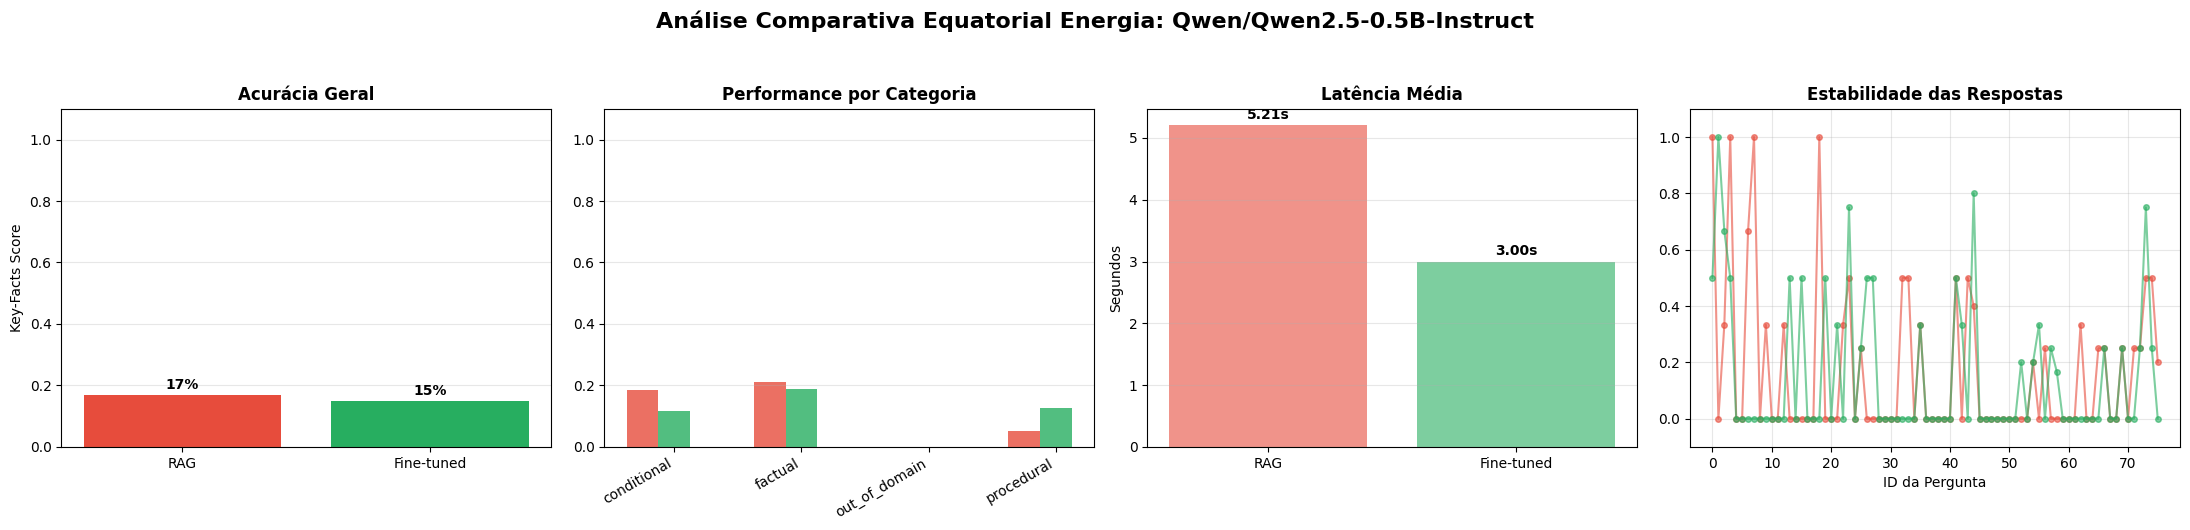

In [91]:
fig, axes = plt.subplots(1, 4, figsize=(22, 5))

names_plot = list(all_approaches.keys())
colors = ["#e74c3c", "#27ae60", "#3498db"]  # Vermelho (Base), Verde (RAG), Azul (FT)

means = [np.mean(scores[n]) for n in names_plot]
axes[0].bar(names_plot, means, color=colors)
axes[0].set_ylabel("Key-Facts Score")
axes[0].set_title("Acurácia Geral", fontweight="bold")
axes[0].set_ylim(0, 1.1)
axes[0].grid(True, alpha=0.3, axis="y")
for i, v in enumerate(means):
    axes[0].text(i, v + 0.02, f"{v:.0%}", ha="center", fontweight="bold")

types = sorted(set(item["type"] for item in BENCHMARK))
x = np.arange(len(types))
width = 0.25
for i, (name, color) in enumerate(zip(names_plot, colors)):
    type_means = [
        np.mean(scores_by_type[name][t]) if scores_by_type[name][t] else 0
        for t in types
    ]
    axes[1].bar(x + i * width, type_means, width, label=name, color=color, alpha=0.8)

axes[1].set_xticks(x + width)
axes[1].set_xticklabels(types, rotation=30, ha="right")
axes[1].set_title("Performance por Categoria", fontweight="bold")
axes[1].set_ylim(0, 1.1)
axes[1].grid(True, alpha=0.3, axis="y")

mean_latencies = [np.mean(latencies[n]) if latencies[n] else 0 for n in names_plot]
axes[2].bar(names_plot, mean_latencies, color=colors, alpha=0.6)
axes[2].set_ylabel("Segundos")
axes[2].set_title("Latência Média", fontweight="bold")
axes[2].grid(True, alpha=0.3, axis="y")
for i, v in enumerate(mean_latencies):
    axes[2].text(i, v + 0.1, f"{v:.2f}s", ha="center", fontweight="bold")

n_q = len(BENCHMARK)
for name, color in zip(names_plot, colors):
    axes[3].plot(
        range(n_q), scores[name], "o-", color=color, label=name, alpha=0.6, markersize=4
    )
axes[3].set_xlabel("ID da Pergunta")
axes[3].set_title("Estabilidade das Respostas", fontweight="bold")
axes[3].set_ylim(-0.1, 1.1)
axes[3].grid(True, alpha=0.3)

plt.suptitle(
    f"Análise Comparativa Equatorial Energia: {MODEL_ID}",
    fontsize=16,
    fontweight="bold",
    y=1.05,
)
plt.tight_layout()
plt.show()